## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                            precision_score, recall_score, f1_score)

import warnings
warnings.filterwarnings('ignore')


## 2. Data Loading

In [12]:
# Load the dataset
df = pd.read_csv(r'C:\Users\prave\OneDrive\Desktop\customer-churn-intelligence\data\churn.csv')

print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print(f"Column names: {df.columns.tolist()}")
df.head()

Number of rows: 7043, Number of columns: 21
Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Data types overview
print("Data Types:")
print(df.dtypes.to_string())


Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


In [16]:
# check for missing values and duplicates
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [22]:
# convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# check for missing values again after conversion
print("Missing values after conversion:")   
print(f"Nan in TotalCharges: {df['TotalCharges'].isnull().sum()}")

print("Those are likely due to the fact that 'TotalCharges' is empty for customers with no tenure, so we can fill those NaN values with 0.")
df['TotalCharges'].fillna(0, inplace=True)

print(f"remaining missing values in dataset: {df.isnull().sum().sum()}")

# Drop 'customerID' as it is not useful for analysis
df.drop('customerID', axis=1, inplace=True)

# Encode Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# new df shape
print(f"New dataset shape: {df.shape}")
df.head()


Missing values after conversion:
Nan in TotalCharges: 11
Those are likely due to the fact that 'TotalCharges' is empty for customers with no tenure, so we can fill those NaN values with 0.
remaining missing values in dataset: 0
New dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [33]:
print("0 means Not Churned, 1 means Churned. \nChurned means the customer has left the company, while Not Churned means the customer is still with the company.")

df['Churn'].value_counts()
print(f"Churn distribution:\n{df['Churn'].value_counts()}")

ratio = df['Churn'].value_counts()[1] / df['Churn'].value_counts()[0]
print(f"Churn ratio (Churned/Not Churned): {ratio:.2f}")

0 means Not Churned, 1 means Churned. 
Churned means the customer has left the company, while Not Churned means the customer is still with the company.
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn ratio (Churned/Not Churned): 0.36


In [ ]:
# show me rows where total charges is 0
print("Rows where TotalCharges is 0:")
print(df[df['TotalCharges'] == 0][['tenure', 'TotalCharges', 'Churn']])

## 3. Business KPIs

Before any modelling, we calculate the headline numbers a stakeholder would see on a dashboard.


In [71]:

total_customers = df.shape[0]
print(f"Total Customers: {total_customers}")

churned_customers = df['Churn'].sum()
print(f"Churned Customers: {churned_customers}")

churn_rate = (churned_customers / total_customers) * 100
print(f"\nChurn Rate: {churn_rate:.2f}%")

average_monthly_charges = df['MonthlyCharges'].mean()
print(f"\nAverage Monthly Charges: ${average_monthly_charges:.2f}")

average_total_charges = df['TotalCharges'].mean()
print(f"Average Total Charges: ${average_total_charges:.2f}")

average_tenure_churned = df[df['Churn'] == 1]['tenure'].mean()
print(f"Average Tenure Churned: {average_tenure_churned:.2f} months")

average_tenure_retained = df[df['Churn'] == 0]['tenure'].mean()
print(f"Average Tenure Retained: {average_tenure_retained:.2f} months")

revenue_lost = df[df['Churn'] == 1]['MonthlyCharges'].sum()
print(f"\nTotal Revenue Lost from Churned Customers: ${revenue_lost:,.2f}")

churn_per_contract = df.groupby('Contract')['Churn'].mean().reset_index()
print("\nChurn Rate by Contract Type:")
print(churn_per_contract)

print("\nKey Insights:")
print(f"• Approximately one in four customers are leaving the company")
print(f"• On average, churned customers stayed for {average_tenure_churned:.2f} months before leaving")
print(f"• On average, loyal customers stayed for {average_tenure_retained:.2f} months")
print(f"• The company is losing ${revenue_lost:,.2f} in monthly revenue from churned customers")
print(f"• month-to-month contracts have the highest churn rate ({churn_per_contract[churn_per_contract['Contract'] == 'Month-to-month']['Churn'].iloc[0]:.2f}%), followed by one-year and two-year contracts")



Total Customers: 7043
Churned Customers: 1869

Churn Rate: 26.54%

Average Monthly Charges: $64.76
Average Total Charges: $2279.73
Average Tenure Churned: 17.98 months
Average Tenure Retained: 37.57 months

Total Revenue Lost from Churned Customers: $139,130.85

Churn Rate by Contract Type:
         Contract     Churn
0  Month-to-month  0.427097
1        One year  0.112695
2        Two year  0.028319
• month-to-month contracts have the highest churn rate (0.43%), followed by one-year and two-year contracts

Key Insights:
• Approximately one in four customers are leaving the company
• On average, churned customers stayed for 17.98 months before leaving
• On average, loyal customers stayed for 37.57 months
• The company is losing $139,130.85 in monthly revenue from churned customers


## 4. SQL Analytics

Same questions can be answered with SQL (as they often are in real analytics environments).


In [62]:
# Load the dataset into a SQLite database
conn = sqlite3.connect('customers.db')
df.to_sql('churn_data', conn, if_exists='replace', index=False)

print("Dataset loaded into SQLite database 'customers.db' with table name 'churn_data'.")
columns = df.columns.tolist()
print(f"Columns in the database: {columns}")

Dataset loaded into SQLite database 'customers.db' with table name 'churn_data'.
Columns in the database: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [63]:
# Helper Functions for SQL Queries
# Use this function to execute SQL queries on the 'customers.db' database and return results as a DataFrame

def execute_query(query):
    with conn:
        return pd.read_sql_query(query, conn)


In [91]:
# Q1. Overall Churn Distribution
query_churn_distribution = ("""
SELECT Churn, COUNT(*) AS Count, ROUND((COUNT(*) * 100.0) / (SELECT COUNT(*) FROM churn_data), 2) AS Percentage
FROM churn_data
GROUP BY Churn
""")
churn_distribution = execute_query(query_churn_distribution)
print("Churn Distribution:")
print(churn_distribution)

# Q2. Churn Rate by Contract Type
query_churn_by_contract = ("""
SELECT Contract, ROUND(AVG(Churn) * 100.0, 2) AS ChurnRate, COUNT(*) AS ChurnedCustomers
FROM churn_data
GROUP BY Contract
ORDER BY ChurnRate DESC
""")
churn_by_contract = execute_query(query_churn_by_contract)
print("\nChurn Rate by Contract Type:")
print(churn_by_contract)

# Q3. Revenue Lost from Churned Customers
query_revenue_lost = ("""
SELECT Contract, ROUND(SUM(MonthlyCharges), 2) AS TotalRevenueLost, COUNT(*) AS ChurnedCustomers
FROM churn_data
WHERE Churn = 1
GROUP BY Contract
""")
revenue_lost = execute_query(query_revenue_lost)
print("\nRevenue Lost from Churned Customers:")
print(revenue_lost)

# Q4. Payment Method and Churn
query_payment_churn = ("""
SELECT PaymentMethod, ROUND(AVG(Churn) * 100.0, 2) AS ChurnRate, COUNT(*) AS CustomerCount
FROM churn_data 
GROUP BY PaymentMethod
ORDER BY ChurnRate DESC
""")
payment_churn = execute_query(query_payment_churn)
print("\nChurn Rate by Payment Method:")
print(payment_churn)


# Q5. Tenure Segmentation
query_tenure_segmentation = ("""
SELECT 
    CASE 
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure > 12 AND tenure <= 24 THEN '13-24 months'
        WHEN tenure > 24 AND tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS TenureSegment,
    ROUND(AVG(Churn) * 100.0, 2) AS ChurnRate,
    COUNT(*) AS CustomerCount
FROM churn_data
GROUP BY TenureSegment
ORDER BY ChurnRate DESC
""")    
tenure_segmentation = execute_query(query_tenure_segmentation)
print("\nChurn Rate by Tenure Segmentation:")
print(tenure_segmentation)

Churn Distribution:
   Churn  Count  Percentage
0      0   5174       73.46
1      1   1869       26.54

Churn Rate by Contract Type:
         Contract  ChurnRate  ChurnedCustomers
0  Month-to-month      42.71              3875
1        One year      11.27              1473
2        Two year       2.83              1695

Revenue Lost from Churned Customers:
         Contract  TotalRevenueLost  ChurnedCustomers
0  Month-to-month         120847.10              1655
1        One year          14118.45               166
2        Two year           4165.30                48

Churn Rate by Payment Method:
               PaymentMethod  ChurnRate  CustomerCount
0           Electronic check      45.29           2365
1               Mailed check      19.11           1612
2  Bank transfer (automatic)      16.71           1544
3    Credit card (automatic)      15.24           1522

Churn Rate by Tenure Segmentation:
  TenureSegment  ChurnRate  CustomerCount
0   0-12 months      47.44           218

## 5. Exploratory Data Analysis

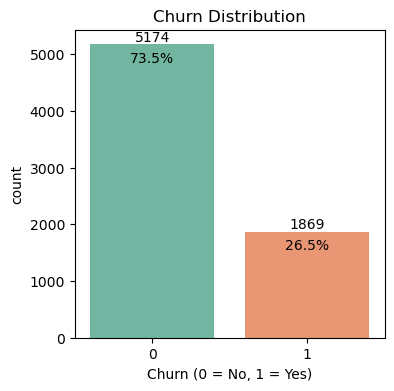

In [125]:
# 1. EDA of Churn Distribution
plt.figure(figsize=(4, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
ax = plt.gca()
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0,0.1), textcoords='offset points')

# percentage labels
total = len(df)
for p in ax.patches:
    percentage = (p.get_height() / total) * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, -15), textcoords='offset points')



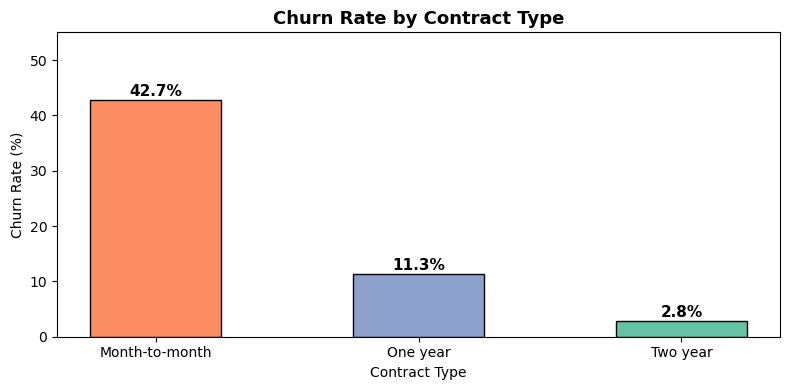

In [122]:
# 2. Churn by Contract Type

contract_churn = df.groupby('Contract')['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['#fc8d62', '#8da0cb', '#66c2a5'], edgecolor='black', width=0.5)
ax.set_title('Churn Rate by Contract Type', fontweight='bold', fontsize=13)
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.set_ylim(0, 55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(" Insight: Month-to-month customers churn at ~43% vs ~11% (1-year) and ~3% (2-year).")
print(" Converting even 20% of M2M customers to annual plans will be significant.")



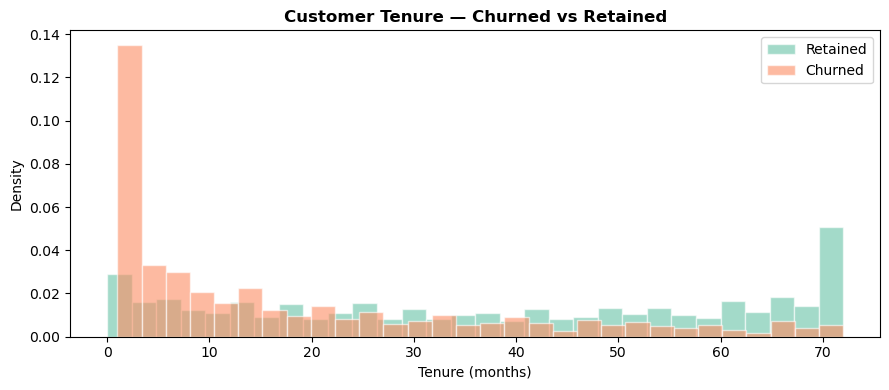

 Insight: Most churners leave within the first 12 months.
 The first year is the critical retention window — onboarding quality matters most.


In [130]:
# 3. Customer tenure distribution by churn
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0, '#66c2a5', 'Retained'), (1, '#fc8d62', 'Churned')]:
    ax.hist(df[df['Churn'] == label]['tenure'], bins=30,
            alpha=0.6, color=color, label=name, edgecolor='white', density=True)
ax.set_title('Customer Tenure — Churned vs Retained', fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print(" Insight: Most churners leave within the first 12 months.")
print(" The first year is the critical retention window — onboarding quality matters most.")

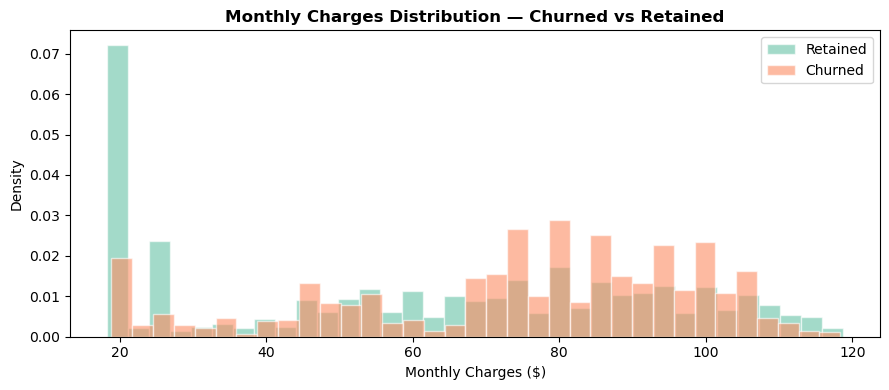

 Insight: Churned customers pay significantly higher monthly charges.
 High-value customers who feel they aren't getting value are most at risk.


In [132]:
# 4. Monthly Charges Distribution by Churn
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0, '#66c2a5', 'Retained'), (1, '#fc8d62', 'Churned')]:
    ax.hist(df[df['Churn'] == label]['MonthlyCharges'], bins=35,
            alpha=0.6, color=color, label=name, edgecolor='white', density=True)
ax.set_title('Monthly Charges Distribution — Churned vs Retained', fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print(" Insight: Churned customers pay significantly higher monthly charges.")
print(" High-value customers who feel they aren't getting value are most at risk.")

In [ ]:
# 5. Correlation Heat Map

num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].copy()
corr = num_df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()




